In [47]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import normalize, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [48]:
df = pd.read_csv("../data/spotify_tracks_clean.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min,key_label,mode_label
0,20001,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,...,0.01300,0.000005,0.2660,0.238,131.121,4,dance,2.615717,D,Major
1,51664,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,...,0.01250,0.033000,0.2300,0.550,128.033,4,hip-hop,3.315617,D,Major
2,81210,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,...,0.00383,0.000007,0.3710,0.304,128.040,4,pop,2.920633,G,Minor
3,89411,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,...,0.58300,0.000002,0.2180,0.850,124.980,4,reggaeton,2.710617,G,Minor
4,68305,6Sq7ltF9Qa7SNFBsV5Cogx,Bad Bunny;Chencho Corleone,Un Verano Sin Ti,Me Porto Bonito,97,178567,True,0.911,0.712,...,0.09010,0.000027,0.0933,0.425,92.005,4,latino,2.976117,C♯,Minor


**EDA**

In [49]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

Series([], dtype: int64)


In [50]:
print(df.dtypes)

Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
duration_min        float64
key_label            object
mode_label           object
dtype: object


In [51]:
genre_counts = df["track_genre"].value_counts()
print(f"Num of unique genres: {len(genre_counts)}")
print(f"Min samples per genre: {genre_counts.min()}")
print(f"Max samples per genre: {genre_counts.max()}")
print(genre_counts.head(5))

Num of unique genres: 114
Min samples per genre: 329
Max samples per genre: 999
track_genre
tango        999
sleep        998
study        998
idm          997
grindcore    993
Name: count, dtype: int64


In [52]:
print(f"Rows where tempo == 0: {(df['tempo'] == 0).sum()}")

Rows where tempo == 0: 157


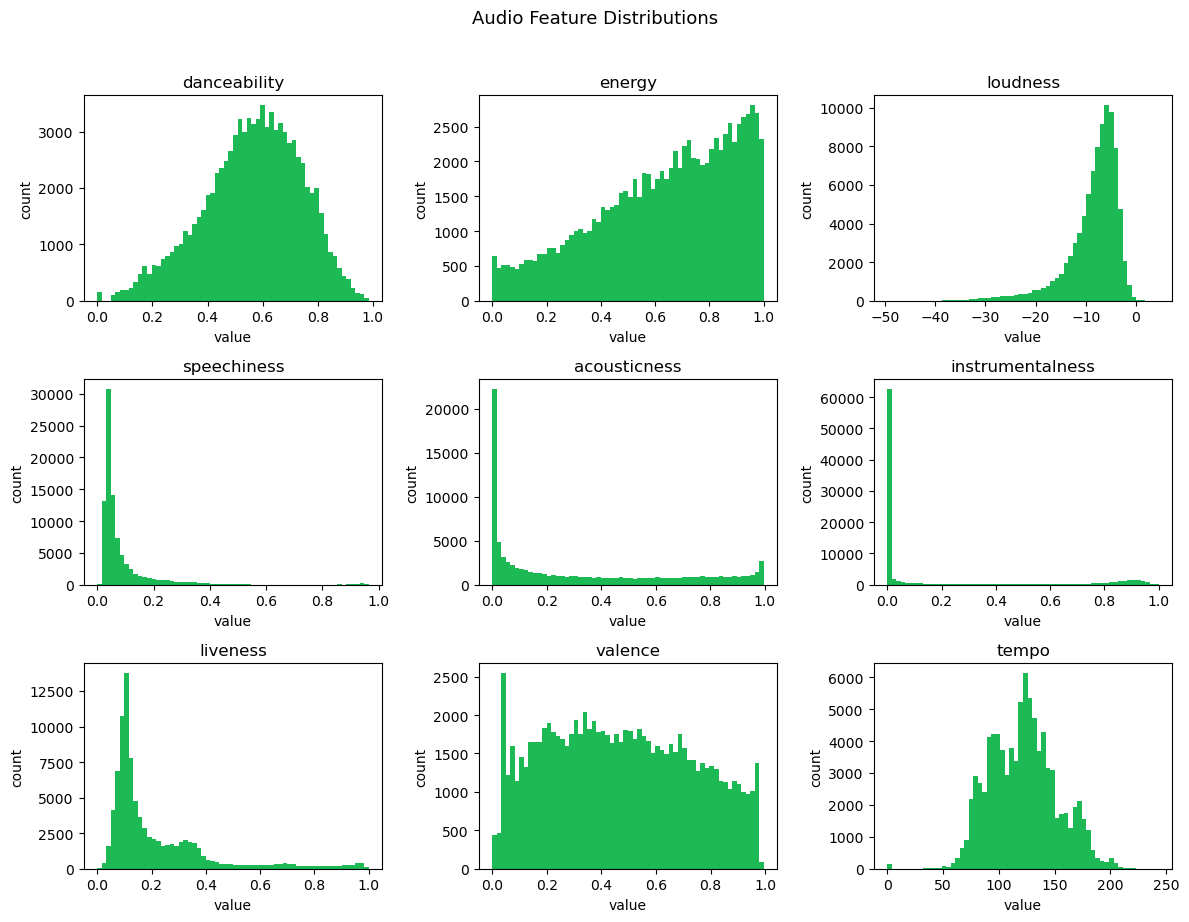

In [53]:
audio_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    axes[i].hist(df[feature], color="#1DB954", bins=60, edgecolor="none")
    axes[i].set_title(feature)
    axes[i].set_xlabel("value")
    axes[i].set_ylabel("count")

plt.suptitle("Audio Feature Distributions", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Correlation Analysis**

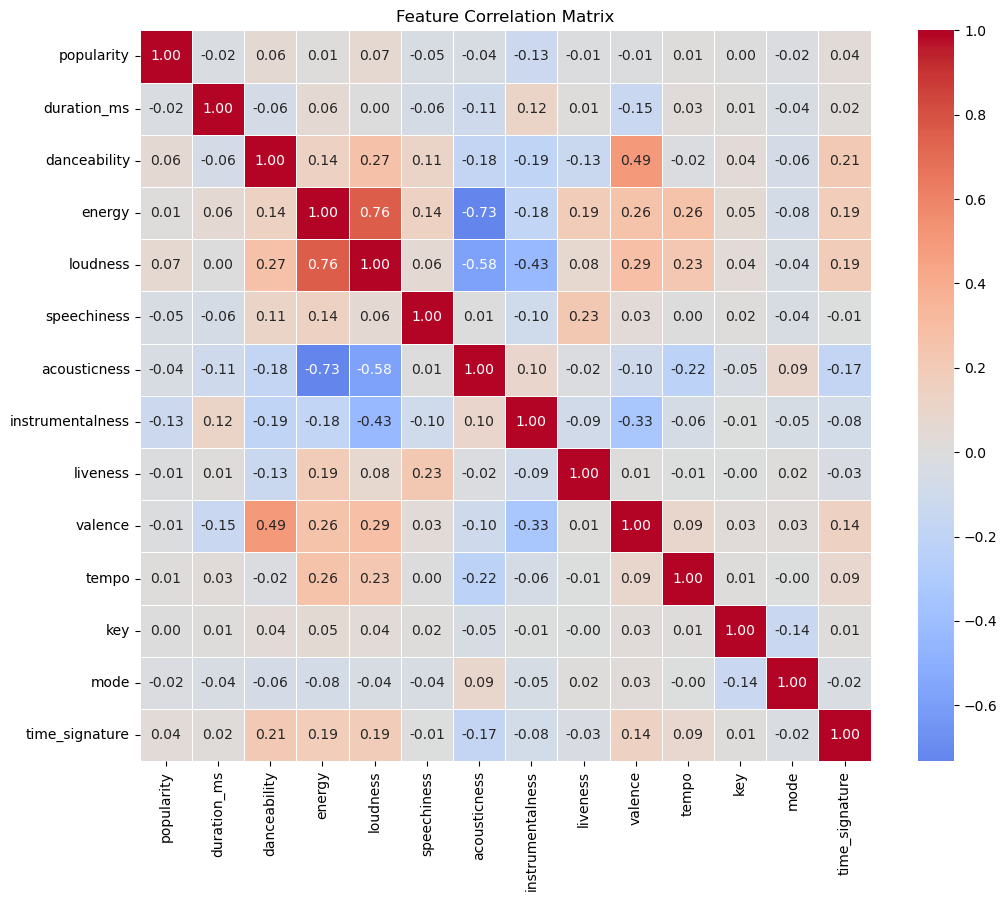

In [54]:
numeric_features = [
    "popularity", "duration_ms", "danceability", "energy", "loudness",
    "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "key", "mode", "time_signature"
]

corr_matrix = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.4,
    ax=ax
)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [55]:
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            print(f"{corr_matrix.columns[i]:20s} vs {corr_matrix.columns[j]:20s}  r = {r:.3f}")

energy               vs loudness              r = 0.759
energy               vs acousticness          r = -0.733
loudness             vs acousticness          r = -0.583


In [56]:
scale_summary = df[numeric_features].agg(["min", "max", "mean", "std"]).T
scale_summary.columns = ["min", "max", "mean", "std"]
print(scale_summary.round(3).to_string())

                       min          max        mean         std
popularity           0.000      100.000      33.208      20.574
duration_ms       8586.000  5237295.000  229144.366  112945.780
danceability         0.000        0.985       0.562       0.177
energy               0.000        1.000       0.634       0.257
loudness           -49.531        4.532      -8.499       5.222
speechiness          0.000        0.965       0.087       0.113
acousticness         0.000        0.996       0.328       0.338
instrumentalness     0.000        1.000       0.173       0.324
liveness             0.000        1.000       0.217       0.195
valence              0.000        0.995       0.469       0.263
tempo                0.000      243.372     122.058      30.118
key                  0.000       11.000       5.284       3.560
mode                 0.000        1.000       0.637       0.481
time_signature       0.000        5.000       3.897       0.453


**Cleaning**

In [57]:
df_clean = df.drop_duplicates(subset="track_id", keep="first").copy()
print(f"After dedup by track_id: {df_clean.shape}")

After dedup by track_id: (89740, 24)


In [58]:
metadata_cols = ["Unnamed: 0", "track_id", "artists", "album_name", "track_name"]

metadata = df_clean[["track_name", "artists", "track_genre"]].copy()
df_clean = df_clean.drop(columns=metadata_cols)
print(f"After dropping metadata cols: {df_clean.shape}")

After dropping metadata cols: (89740, 19)


In [59]:
df_clean = df_clean.dropna()
metadata = metadata.loc[df_clean.index]
print(f"After dropping null rows: {df_clean.shape}")

After dropping null rows: (89740, 19)


In [60]:
#remove tempo since there can be no songs with 0 tempo
#this means if it is 0, it is invalid data
tempo_mask = df_clean["tempo"] != 0

df_clean = df_clean[tempo_mask].reset_index(drop=True)
metadata = metadata[tempo_mask.values].reset_index(drop=True)
print(f"After filtering tempo = 0: {df_clean.shape}")

After filtering tempo = 0: (89583, 19)


In [61]:
df_clean["explicit"] = df_clean["explicit"].astype(int)

In [62]:
print(f"\nFinal cleaned shape: {df_clean.shape}")
print(f"\nDtypes after encoding:")
print(df_clean.dtypes)
print(f"\nRemaining nulls: {df_clean.isnull().sum().sum()}")


Final cleaned shape: (89583, 19)

Dtypes after encoding:
popularity            int64
duration_ms           int64
explicit              int32
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
duration_min        float64
key_label            object
mode_label           object
dtype: object

Remaining nulls: 0


In [63]:
feature_cols = [
    "popularity", "duration_ms", "danceability", "energy", "loudness",
    "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "key", "mode", "time_signature", "explicit", "genre_encoded"
]

In [64]:
le = LabelEncoder()
df_clean["genre_encoded"] = le.fit_transform(
    metadata["track_genre"]
)

print(f"Unique genre codes: {df_clean['genre_encoded'].nunique()}")
print(f"Sample mapping:")
for genre, code in zip(le.classes_[:5], range(5)):
    print(f"  {genre} → {code}")

Unique genre codes: 114
Sample mapping:
  acoustic → 0
  afrobeat → 1
  alt-rock → 2
  alternative → 3
  ambient → 4


In [65]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[feature_cols])

print(f"X_scaled shape: {X_scaled.shape}")

X_scaled shape: (89583, 16)


In [66]:
feature_weights = {
    "popularity": 1.0,
    "duration_ms": 1.0,
    "danceability": 1.0,
    "energy": 1.0,
    "loudness": 1.0,
    "speechiness": 1.0,
    "acousticness": 1.0,
    "instrumentalness": 1.0,
    "liveness": 1.0,
    "valence": 1.0,
    "tempo": 1.0,
    "key": 1.0,
    "mode": 3.0,
    "time_signature": 1.0,
    "explicit": 1.0,
    "genre_encoded": 5.0
}

weight_vector = np.array([feature_weights[col] for col in feature_cols])
X_weighted = X_scaled * weight_vector

print(f"Weight vector: {weight_vector}")
print(f"X_weighted shape: {X_weighted.shape}")

Weight vector: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 3. 1. 1. 5.]
X_weighted shape: (89583, 16)


In [67]:
scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

verification = scaled_df.agg(["mean", "std"]).T
verification.columns = ["mean", "std"]
print(verification.round(4).to_string())

                  mean  std
popularity        -0.0  1.0
duration_ms        0.0  1.0
danceability       0.0  1.0
energy            -0.0  1.0
loudness           0.0  1.0
speechiness        0.0  1.0
acousticness       0.0  1.0
instrumentalness   0.0  1.0
liveness          -0.0  1.0
valence           -0.0  1.0
tempo              0.0  1.0
key               -0.0  1.0
mode              -0.0  1.0
time_signature    -0.0  1.0
explicit          -0.0  1.0
genre_encoded      0.0  1.0


**Dimensionality Reduction**

In [68]:
pca = PCA()
pca.fit(X_scaled)


cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print("=== Explained variance by component ===")
for i, (individual, cumulative) in enumerate(
    zip(pca.explained_variance_ratio_, cumulative_variance), start=1
):
    print(f"PC{i:02d}:  {individual:.4f}  cumulative: {cumulative:.4f}")

=== Explained variance by component ===
PC01:  0.1866  cumulative: 0.1866
PC02:  0.0984  cumulative: 0.2849
PC03:  0.0891  cumulative: 0.3740
PC04:  0.0765  cumulative: 0.4505
PC05:  0.0685  cumulative: 0.5190
PC06:  0.0658  cumulative: 0.5848
PC07:  0.0616  cumulative: 0.6464
PC08:  0.0556  cumulative: 0.7020
PC09:  0.0551  cumulative: 0.7571
PC10:  0.0525  cumulative: 0.8097
PC11:  0.0515  cumulative: 0.8611
PC12:  0.0456  cumulative: 0.9068
PC13:  0.0370  cumulative: 0.9437
PC14:  0.0274  cumulative: 0.9712
PC15:  0.0202  cumulative: 0.9914
PC16:  0.0086  cumulative: 1.0000


In [69]:
pca = PCA(n_components=0.90, svd_solver="full")
X_pca = pca.fit_transform(X_weighted)

print(f"Components retained: {pca.n_components_}")
print(f"Explained variance captured: {pca.explained_variance_ratio_.sum():.4f}")
print(f"X_pca shape: {X_pca.shape}")

Components retained: 9
Explained variance captured: 0.9175
X_pca shape: (89583, 9)


In [70]:
X_norm = normalize(X_pca, norm="l2")

print(f"X_norm shape: {X_norm.shape}")

X_norm shape: (89583, 9)


In [71]:
row_norms = np.linalg.norm(X_norm, axis=1)
print(f"Row norm min:  {row_norms.min():.6f}")
print(f"Row norm max:  {row_norms.max():.6f}")
print(f"Row norm mean: {row_norms.mean():.6f}")

Row norm min:  1.000000
Row norm max:  1.000000
Row norm mean: 1.000000


In [72]:
pre_norm_magnitudes = np.linalg.norm(X_pca, axis=1)
near_zero_threshold = 0.1
near_zero_count = (pre_norm_magnitudes < near_zero_threshold).sum()

print(f"Rows with pre-normalization magnitude < {near_zero_threshold}: {near_zero_count}")
print(f"As % of dataset: {near_zero_count / len(X_pca) * 100:.3f}%")

Rows with pre-normalization magnitude < 0.1: 0
As % of dataset: 0.000%


**KNN**

In [73]:
from sklearn.neighbors import NearestNeighbors

knn_index = NearestNeighbors(metric="cosine", algorithm="brute")
knn_index.fit(X_norm)

print(f"Index fitted on: {X_norm.shape[0]} tracks, {X_norm.shape[1]} dimensions")

Index fitted on: 89583 tracks, 9 dimensions


In [74]:
name_to_index = {
    name: idx for idx, name in enumerate(metadata["track_name"])
}

print(f"Tracks in lookup: {len(name_to_index)}")
print(f"Sample entries:")
for name in list(name_to_index.keys())[100:104]:
    print(f"  '{name}' → index {name_to_index[name]}")

Tracks in lookup: 73471
Sample entries:
  'Perfect' → index 78514
  'Un Ratito' → index 102
  'Yonaguni' → index 103
  'Feliz Cumpleaños Ferxxo' → index 85500


In [75]:
def recommend_song(track_name, n_recommendations=10):
    if track_name not in name_to_index:
        raise ValueError(f"'{track_name}' not found in index. Check spelling.")

    query_idx = name_to_index[track_name]
    query_vector = X_norm[query_idx].reshape(1, -1)

    distances, indices = knn_index.kneighbors(
        query_vector, n_neighbors=n_recommendations + 1
    )

    similarities = 1 - distances[0]
    neighbor_indices = indices[0]

    results = []
    for sim, idx in zip(similarities, neighbor_indices):
        if idx == query_idx:
            continue
        results.append({
            "track_name": metadata.loc[idx, "track_name"],
            "artists":    metadata.loc[idx, "artists"],
            "genre":      metadata.loc[idx, "track_genre"],
            "similarity": round(sim, 4)
        })

    return pd.DataFrame(results).head(n_recommendations)

In [76]:
results = recommend_song("Rape Me", n_recommendations=10)
print(results.to_string(index=False))

                              track_name           artists     genre  similarity
                                 Rape Me           Nirvana    grunge      0.9892
                           Hunger Strike Temple Of The Dog    grunge      0.9846
                      Other Side of Love     Karen Harding    groove      0.9774
                                   Shine   Collective Soul    grunge      0.9769
                            Given to Fly         Pearl Jam    grunge      0.9764
                                Honestly      Harem Scarem hard-rock      0.9761
I Hate Myself And Want To Die - 2013 Mix           Nirvana    grunge      0.9721
     Cadeias Quebrar (Break Every Chain)     Soraya Moraes    gospel      0.9715
                    When I See You Smile       Bad English hard-rock      0.9708
    Hunger Strike - 25th Anniversary Mix Temple Of The Dog    grunge      0.9708


Validation

In [77]:
def precision_at_k(track_name, k=10):
    query_genre = metadata.loc[
        name_to_index[track_name], "track_genre"
    ]
    recs = recommend_song(track_name, n_recommendations=k)
    matches = (recs["genre"] == query_genre).sum()
    return matches / k

In [78]:
np.random.seed(42)
sample_indices = np.random.choice(len(metadata), size=500, replace=False)
sample_tracks = metadata.loc[sample_indices, "track_name"].tolist()

precisions = []
for track in sample_tracks:
    try:
        p = precision_at_k(track, k=10)
        precisions.append(p)
    except ValueError:
        continue

mean_precision = np.mean(precisions)
median_precision = np.median(precisions)

print(f"Evaluated tracks:  {len(precisions)}")
print(f"Mean Precision@10: {mean_precision:.4f}")
print(f"Median Precision@10: {median_precision:.4f}")
print(f"Random baseline:   {1/114:.4f}")
print(f"Lift over random:  {mean_precision / (1/114):.1f}x")

print(f"Distribution:")
thresholds = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]
for lo, hi in zip(thresholds, thresholds[1:]):
    count = sum(lo <= p < hi for p in precisions)
    print(f"  [{lo:.1f}, {hi:.1f}): {count:4d} tracks  ({count/len(precisions)*100:.1f}%)")

Evaluated tracks:  500
Mean Precision@10: 0.4508
Median Precision@10: 0.4000
Random baseline:   0.0088
Lift over random:  51.4x
Distribution:
  [0.0, 0.1):   60 tracks  (12.0%)
  [0.1, 0.3):  108 tracks  (21.6%)
  [0.3, 0.5):  103 tracks  (20.6%)
  [0.5, 0.7):   78 tracks  (15.6%)
  [0.7, 1.0):  100 tracks  (20.0%)


In [79]:
def recommend_song_reranked(track_name, n_recommendations=10,
                             candidate_pool=50, artist_boost=0.05):
    if track_name not in name_to_index:
        raise ValueError(f"'{track_name}' not found in index.")

    query_idx = name_to_index[track_name]
    query_vector = X_norm[query_idx].reshape(1, -1)
    query_artist = metadata.loc[query_idx, "artists"]

    distances, indices = knn_index.kneighbors(
        query_vector, n_neighbors=candidate_pool + 1
    )
    similarities = 1 - distances[0]

    results = []
    for sim, idx in zip(similarities, indices[0]):
        if idx == query_idx:
            continue

        candidate_artist = metadata.loc[idx, "artists"]

        adjusted_sim = sim + artist_boost if candidate_artist == query_artist else sim

        results.append({
            "track_name":    metadata.loc[idx, "track_name"],
            "artists":       candidate_artist,
            "genre":         metadata.loc[idx, "track_genre"],
            "similarity":    round(sim, 4),
            "adjusted_sim":  round(adjusted_sim, 4)
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(
        "adjusted_sim", ascending=False
    ).head(n_recommendations)

    return results_df.reset_index(drop=True)

In [80]:
recommend_song_reranked("Happy")

,track_name,artists,genre,similarity,adjusted_sim
0,Coronation Rag,Winifred Atwell,honky-tonk,0.9557,0.9557
1,Black And White Rag,Winifred Atwell,honky-tonk,0.9535,0.9535
2,WTF,Still Woozy,indie,0.9511,0.9511
3,WTF,Still Woozy,indie,0.9511,0.9511
4,WTF,Still Woozy,indie,0.9511,0.9511
5,WTF,Still Woozy,indie,0.9511,0.9511
6,There's No Reason to Be Living,Stonewall Jackson,honky-tonk,0.9495,0.9495
7,広い世界,Rei Harakami,idm,0.9464,0.9464
8,Jungle,Swattrex;Lofi By Swattrex;Tracer,indian,0.9454,0.9454
9,Let's Go Home Together,Ella Henderson;Tom Grennan,house,0.9440,0.9440


In [81]:
import joblib
import os

In [82]:
os.makedirs("artifacts", exist_ok=True)

In [83]:
joblib.dump(scaler, "artifacts/scaler.pkl")
joblib.dump(pca, "artifacts/pca.pkl")
joblib.dump(le, "artifacts/label_encoder.pkl")
joblib.dump(knn_index, "artifacts/knn_index.pkl")
joblib.dump(X_norm, "artifacts/X_norm.pkl")
joblib.dump(name_to_index, "artifacts/name_to_index.pkl")
joblib.dump(metadata, "artifacts/metadata.pkl")
joblib.dump(feature_cols, "artifacts/feature_cols.pkl")
joblib.dump(feature_weights, "artifacts/feature_weights.pkl")

['artifacts/feature_weights.pkl']

In [84]:
print("Artifacts saved:")
for f in os.listdir("artifacts"):
    size_mb = os.path.getsize(f"artifacts/{f}") / 1e6
    print(f"  {f}: {size_mb:.1f} MB")

Artifacts saved:
  feature_cols.pkl: 0.0 MB
  feature_weights.pkl: 0.0 MB
  knn_index.pkl: 6.5 MB
  label_encoder.pkl: 0.0 MB
  metadata.pkl: 3.4 MB
  name_to_index.pkl: 1.9 MB
  pca.pkl: 0.0 MB
  scaler.pkl: 0.0 MB
  X_norm.pkl: 6.5 MB


---
## Evaluation & Results

> Quantitative analysis of the KNN recommender: Precision@K, PCA variance, similarity distribution, genre-level recall, and reranking comparison.

In [85]:
# ── 1. Precision@10 — 500-track sample ──
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

SPOTIFY_GREEN = '#1DB954'
BG           = '#FFFFFF'
GRAY         = '#b3b3b3'

np.random.seed(42)
sample_indices = np.random.choice(len(metadata), size=500, replace=False)
sample_tracks  = metadata.loc[sample_indices, 'track_name'].tolist()

precisions = []
for track in sample_tracks:
    try:
        p = precision_at_k(track, k=10)
        precisions.append(p)
    except ValueError:
        continue

mean_prec   = np.mean(precisions)
median_prec = np.median(precisions)
baseline    = 1 / 114

print(f'Evaluated tracks : {len(precisions)}')
print(f'Mean  Precision@10: {mean_prec:.4f}')
print(f'Median Precision@10: {median_prec:.4f}')
print(f'Random baseline    : {baseline:.4f}')
print(f'Lift over random   : {mean_prec / baseline:.1f}x')


Evaluated tracks : 500
Mean  Precision@10: 0.4508
Median Precision@10: 0.4000
Random baseline    : 0.0088
Lift over random   : 51.4x


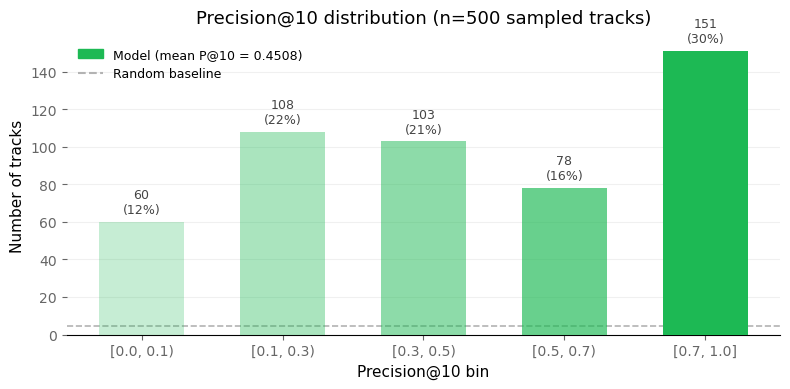

In [86]:
# ── 2. Precision@10 distribution ──
bins    = [0.0, 0.1, 0.3, 0.5, 0.7, 1.01]
labels  = ['[0.0, 0.1)', '[0.1, 0.3)', '[0.3, 0.5)', '[0.5, 0.7)', '[0.7, 1.0]']
counts  = [sum(bins[i] <= p < bins[i+1] for p in precisions) for i in range(len(bins)-1)]
alphas  = [0.25, 0.4, 0.55, 0.75, 1.0]
colors  = [f"#{int(0x1D + (0x1D)*a):02X}{int(0xB9 + (0xB9)*a):02X}{int(0x54 + (0x54)*a):02X}" for a in alphas]
# simpler solid green gradient
bar_colors = ['#1DB95440','#1DB95460','#1DB95480','#1DB954AA',SPOTIFY_GREEN]

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
bars = ax.bar(labels, counts, color=bar_colors, edgecolor='none', width=0.6, zorder=3)

for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{c}\n({c/len(precisions)*100:.0f}%)',
            ha='center', va='bottom', fontsize=9, color='#444')

ax.axhline(len(precisions) * baseline, color=GRAY, linestyle='--', linewidth=1.2, label=f'Random baseline ({baseline:.4f})')
ax.set_xlabel('Precision@10 bin', fontsize=11)
ax.set_ylabel('Number of tracks', fontsize=11)
ax.set_title('Precision@10 distribution (n=500 sampled tracks)', fontsize=13, pad=10)
ax.spines[['top','right','left']].set_visible(False)
ax.yaxis.grid(True, color='#f0f0f0', zorder=0)
ax.tick_params(axis='both', colors='#666')
legend_patch = mpatches.Patch(color=SPOTIFY_GREEN, label=f'Model (mean P@10 = {mean_prec:.4f})')
baseline_line = Line2D([0],[0], color=GRAY, linestyle='--', linewidth=1.5, label='Random baseline')
ax.legend(handles=[legend_patch, baseline_line], fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig('eval_precision_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


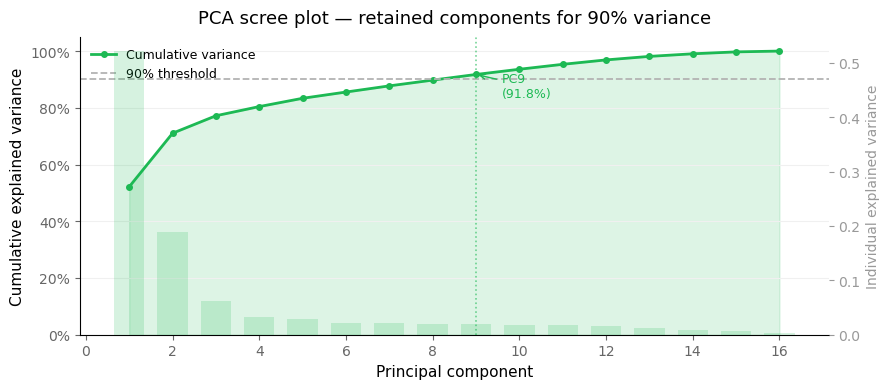

In [87]:
# ── 3. PCA scree plot — explained variance ──
pca_full = __import__('sklearn.decomposition', fromlist=['PCA']).PCA()
pca_full.fit(X_weighted)

evr  = pca_full.explained_variance_ratio_
cumv = np.cumsum(evr)
components = np.arange(1, len(evr) + 1)

fig, ax1 = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor(BG)
ax1.set_facecolor(BG)

ax1.fill_between(components, cumv, alpha=0.15, color=SPOTIFY_GREEN)
ax1.plot(components, cumv, color=SPOTIFY_GREEN, linewidth=2, marker='o', markersize=4, label='Cumulative variance')
ax1.axhline(0.90, color=GRAY, linestyle='--', linewidth=1.3, label='90% threshold')

# mark cutoff
cutoff = np.searchsorted(cumv, 0.90) + 1
ax1.axvline(cutoff, color=SPOTIFY_GREEN, linestyle=':', linewidth=1.2, alpha=0.6)
ax1.annotate(f'PC{cutoff}\n({cumv[cutoff-1]*100:.1f}%)',
             xy=(cutoff, cumv[cutoff-1]),
             xytext=(cutoff+0.6, cumv[cutoff-1]-0.08),
             fontsize=9, color=SPOTIFY_GREEN,
             arrowprops=dict(arrowstyle='->', color=SPOTIFY_GREEN, lw=1))

ax2 = ax1.twinx()
ax2.bar(components, evr, color=SPOTIFY_GREEN, alpha=0.18, width=0.7, label='Individual variance')
ax2.set_ylabel('Individual explained variance', fontsize=10, color='#999')
ax2.tick_params(axis='y', colors='#999')
ax2.spines[['top','right','left','bottom']].set_visible(False)

ax1.set_xlabel('Principal component', fontsize=11)
ax1.set_ylabel('Cumulative explained variance', fontsize=11)
ax1.set_title('PCA scree plot — retained components for 90% variance', fontsize=13, pad=10)
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
ax1.spines[['top','right']].set_visible(False)
ax1.grid(axis='y', color='#f0f0f0')
ax1.tick_params(colors='#666')
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(lines1, labels1, fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig('eval_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()


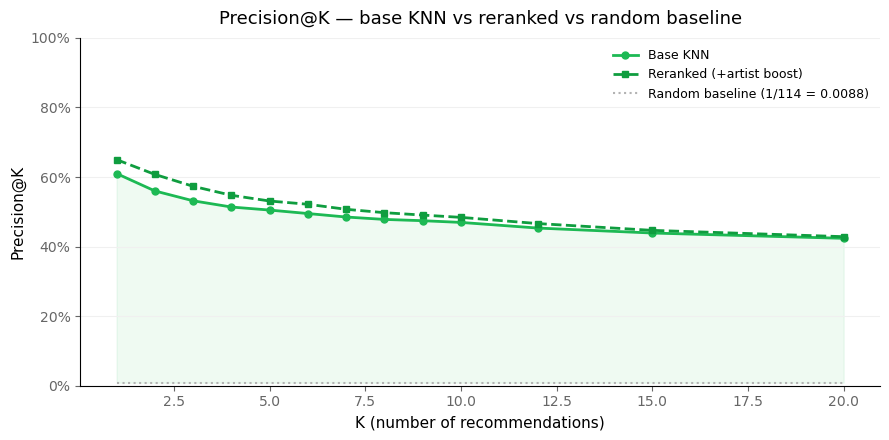

In [88]:
# ── 4. Precision@K curve — base KNN vs reranked vs random ──
def eval_precision_at_k_series(tracks, k_values, reranked=False):
    results = {k: [] for k in k_values}
    for track in tracks:
        genre = metadata.loc[name_to_index[track], 'track_genre']
        max_k = max(k_values)
        try:
            if reranked:
                recs = recommend_song_reranked(track, n_recommendations=max_k)
            else:
                recs = recommend_song(track, n_recommendations=max_k)
            for k in k_values:
                matches = (recs.head(k)['genre'] == genre).sum()
                results[k].append(matches / k)
        except (ValueError, KeyError):
            continue
    return {k: np.mean(v) for k, v in results.items()}

np.random.seed(42)
eval_tracks = metadata.loc[
    np.random.choice(len(metadata), size=200, replace=False), 'track_name'
].tolist()

k_vals = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20]
baseline_curve = {k: 1/114 for k in k_vals}
knn_curve      = eval_precision_at_k_series(eval_tracks, k_vals, reranked=False)
reranked_curve = eval_precision_at_k_series(eval_tracks, k_vals, reranked=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.plot(k_vals, [knn_curve[k] for k in k_vals],
        color=SPOTIFY_GREEN, linewidth=2, marker='o', markersize=5, label='Base KNN')
ax.plot(k_vals, [reranked_curve[k] for k in k_vals],
        color='#0f9d3f', linewidth=2, marker='s', markersize=5, linestyle='--', label='Reranked (+artist boost)')
ax.plot(k_vals, [baseline_curve[k] for k in k_vals],
        color=GRAY, linewidth=1.5, linestyle=':', label=f'Random baseline (1/114 = {1/114:.4f})')

ax.fill_between(k_vals, [knn_curve[k] for k in k_vals],
                [baseline_curve[k] for k in k_vals], alpha=0.07, color=SPOTIFY_GREEN)

ax.set_xlabel('K (number of recommendations)', fontsize=11)
ax.set_ylabel('Precision@K', fontsize=11)
ax.set_title('Precision@K — base KNN vs reranked vs random baseline', fontsize=13, pad=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
ax.set_ylim(0, 1.0)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', color='#f0f0f0')
ax.tick_params(colors='#666')
ax.legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig('eval_precision_at_k.png', dpi=150, bbox_inches='tight')
plt.show()


C:\Users\Robben's Laptop\AppData\Local\Temp\ipykernel_23116\44078833.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genre_sample = metadata.groupby('track_genre').apply(


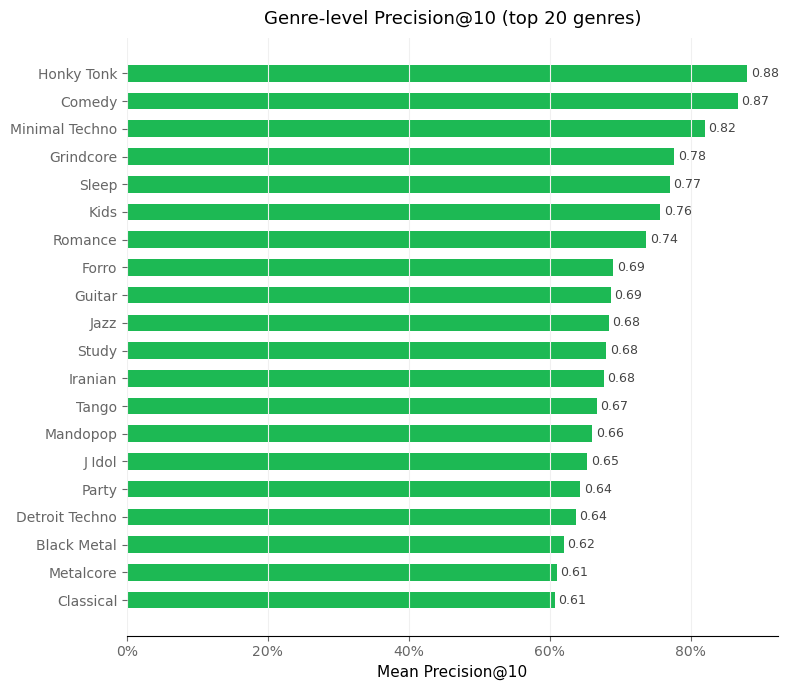

In [89]:
# ── 5. Genre-level Precision@10 ──
from collections import defaultdict

genre_precisions = defaultdict(list)
np.random.seed(42)
genre_sample = metadata.groupby('track_genre').apply(
    lambda g: g.sample(min(30, len(g)), random_state=42)
).reset_index(drop=True)

for _, row in genre_sample.iterrows():
    track = row['track_name']
    genre = row['track_genre']
    if track not in name_to_index:
        continue
    try:
        p = precision_at_k(track, k=10)
        genre_precisions[genre].append(p)
    except ValueError:
        continue

genre_mean = {g: np.mean(v) for g, v in genre_precisions.items() if len(v) >= 5}
genre_sorted = sorted(genre_mean.items(), key=lambda x: x[1], reverse=True)
genres, scores = zip(*genre_sorted[:20])  # top 20

# horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

norm_scores = np.array(scores)
bar_colors  = [SPOTIFY_GREEN if s >= 0.6 else ('#1DB95488' if s >= 0.4 else '#1DB95440') for s in norm_scores]
bars = ax.barh(range(len(genres)), norm_scores, color=bar_colors, edgecolor='none', height=0.6)

ax.set_yticks(range(len(genres)))
ax.set_yticklabels([g.replace('-',' ').title() for g in genres], fontsize=10)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
ax.set_xlabel('Mean Precision@10', fontsize=11)
ax.set_title('Genre-level Precision@10 (top 20 genres)', fontsize=13, pad=10)
ax.spines[['top','right','left']].set_visible(False)
ax.xaxis.grid(True, color='#f0f0f0', zorder=0)
ax.tick_params(axis='both', colors='#666')

for bar, s in zip(bars, norm_scores):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{s:.2f}', va='center', fontsize=9, color='#444')

plt.tight_layout()
plt.savefig('eval_genre_precision.png', dpi=150, bbox_inches='tight')
plt.show()


C:\Users\Robben's Laptop\AppData\Local\Temp\ipykernel_23116\3662492445.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([sims_top10[:, i] for i in range(10)],


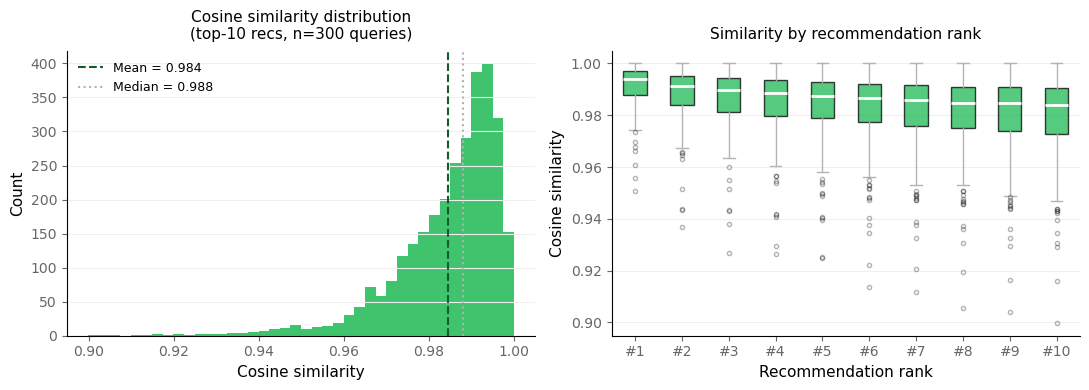

In [90]:
# ── 6. Cosine similarity score distribution ──
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)
sim_sample_idx = np.random.choice(len(X_norm), size=300, replace=False)
sim_query      = X_norm[sim_sample_idx]

dists, _ = knn_index.kneighbors(sim_query, n_neighbors=11)
sims_top10 = 1 - dists[:, 1:]  # exclude self
all_sims   = sims_top10.flatten()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.patch.set_facecolor(BG)

# histogram
ax = axes[0]
ax.set_facecolor(BG)
ax.hist(all_sims, bins=40, color=SPOTIFY_GREEN, edgecolor='none', alpha=0.85)
ax.axvline(np.mean(all_sims), color='#0f5d2a', linestyle='--', linewidth=1.5, label=f'Mean = {np.mean(all_sims):.3f}')
ax.axvline(np.median(all_sims), color=GRAY, linestyle=':', linewidth=1.5, label=f'Median = {np.median(all_sims):.3f}')
ax.set_xlabel('Cosine similarity', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Cosine similarity distribution\n(top-10 recs, n=300 queries)', fontsize=11, pad=8)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', color='#f0f0f0')
ax.tick_params(colors='#666')
ax.legend(fontsize=9, frameon=False)

# boxplot per rank position
ax2 = axes[1]
ax2.set_facecolor(BG)
bp = ax2.boxplot([sims_top10[:, i] for i in range(10)],
                 labels=[f'#{i+1}' for i in range(10)],
                 patch_artist=True,
                 medianprops=dict(color='white', linewidth=2),
                 boxprops=dict(facecolor=SPOTIFY_GREEN, alpha=0.75),
                 whiskerprops=dict(color=GRAY),
                 capprops=dict(color=GRAY),
                 flierprops=dict(marker='o', color=GRAY, alpha=0.3, markersize=3))
ax2.set_xlabel('Recommendation rank', fontsize=11)
ax2.set_ylabel('Cosine similarity', fontsize=11)
ax2.set_title('Similarity by recommendation rank', fontsize=11, pad=8)
ax2.spines[['top','right']].set_visible(False)
ax2.grid(axis='y', color='#f0f0f0')
ax2.tick_params(colors='#666')

plt.tight_layout()
plt.savefig('eval_similarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [91]:
# ── 7. Evaluation summary table ──
import pandas as pd

summary = pd.DataFrame({
    'Metric': [
        'Mean Precision@10',
        'Median Precision@10',
        'Random baseline (1/114)',
        'Lift over random',
        'PCA components retained',
        'Cumulative variance (PCA)',
        'Mean cosine similarity',
        'Tracks indexed',
        'Evaluation sample size',
    ],
    'Base KNN': [
        f'{mean_prec:.4f}',
        f'{median_prec:.4f}',
        f'{baseline:.4f}',
        f'{mean_prec/baseline:.1f}x',
        f'{pca.n_components_}',
        f'{pca.explained_variance_ratio_.sum():.4f}',
        '—',
        f'{X_norm.shape[0]:,}',
        '500',
    ]
})

print(summary.to_string(index=False))


                   Metric Base KNN
        Mean Precision@10   0.4508
      Median Precision@10   0.4000
  Random baseline (1/114)   0.0088
         Lift over random    51.4x
  PCA components retained        9
Cumulative variance (PCA)   0.9175
   Mean cosine similarity        —
           Tracks indexed   89,583
   Evaluation sample size      500
